In [15]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import CIFAR100
from pathlib import Path
import os
from PIL import Image
import matplotlib.pyplot as plt
import random

In [16]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
transform = transforms.Compose([transforms.Resize((32,32)), transforms.RandomHorizontalFlip(p=0.5), transforms.RandomRotation(15),
                               transforms.RandomCrop(32,padding=4,padding_mode='reflect'),transforms.ToTensor()])

In [18]:
train_data = CIFAR100(root='data', train=True, download=True, transform=transform)
test_data = CIFAR100(root='data', train=False, download=True, transform=transform)

In [19]:
train_data.classes

['apple',
 'aquarium_fish',
 'baby',
 'bear',
 'beaver',
 'bed',
 'bee',
 'beetle',
 'bicycle',
 'bottle',
 'bowl',
 'boy',
 'bridge',
 'bus',
 'butterfly',
 'camel',
 'can',
 'castle',
 'caterpillar',
 'cattle',
 'chair',
 'chimpanzee',
 'clock',
 'cloud',
 'cockroach',
 'couch',
 'crab',
 'crocodile',
 'cup',
 'dinosaur',
 'dolphin',
 'elephant',
 'flatfish',
 'forest',
 'fox',
 'girl',
 'hamster',
 'house',
 'kangaroo',
 'keyboard',
 'lamp',
 'lawn_mower',
 'leopard',
 'lion',
 'lizard',
 'lobster',
 'man',
 'maple_tree',
 'motorcycle',
 'mountain',
 'mouse',
 'mushroom',
 'oak_tree',
 'orange',
 'orchid',
 'otter',
 'palm_tree',
 'pear',
 'pickup_truck',
 'pine_tree',
 'plain',
 'plate',
 'poppy',
 'porcupine',
 'possum',
 'rabbit',
 'raccoon',
 'ray',
 'road',
 'rocket',
 'rose',
 'sea',
 'seal',
 'shark',
 'shrew',
 'skunk',
 'skyscraper',
 'snail',
 'snake',
 'spider',
 'squirrel',
 'streetcar',
 'sunflower',
 'sweet_pepper',
 'table',
 'tank',
 'telephone',
 'television',
 'tig

In [20]:
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=0)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=0)

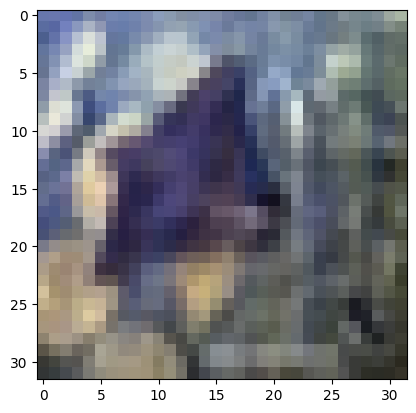

In [21]:
img, label = train_data[random.randint(0,len(train_data))]
plt.imshow(img.permute(1,2,0))

In [22]:
class CifarModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(nn.Conv2d(3,32,kernel_size=3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.Conv2d(32,32,kernel_size=3,padding=1), 
                                    nn.BatchNorm2d(32),nn.ReLU(), nn.Dropout(p=0.25),nn.MaxPool2d(kernel_size=2))
        self.layer2 = nn.Sequential(nn.Conv2d(32,64,kernel_size=3,padding=1), nn.BatchNorm2d(64),nn.ReLU(), nn.Conv2d(64,64,kernel_size=3,padding=1), 
                                    nn.BatchNorm2d(64),nn.ReLU(), nn.Dropout(p=0.25),nn.MaxPool2d(kernel_size=2))
        self.layer3 = nn.Sequential(nn.Flatten(), nn.Dropout(p=0.5), nn.Linear(64*8*8, 512), nn.BatchNorm1d(512),
                                    nn.ReLU(), nn.Linear(512,100))
    def forward(self, x):
        x1 = self.layer1(x)
        x2 = self.layer2(x1)
        return self.layer3(x2)
model = CifarModel().to(device)

In [23]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [24]:
scheduler = torch.optim.lr_scheduler.StepLR(optimizer,step_size=5,gamma=0.8)

In [25]:
def acc_fn(pred,y):
    pred = pred.argmax(dim=1)
    acc = torch.eq(pred,y).sum().item()/len(pred)
    return acc*100

In [26]:
def train_step(model,dataloader=train_dataloader,loss_fn=loss_fn,optimizer=optimizer,device=device):
    model.train()
    acc = 0
    floss = 0
    for X,y in dataloader:
        X,y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = loss_fn(logits,y)
        loss.backward()
        optimizer.step()
        acc += acc_fn(logits, y)
        floss +=loss.item()
    return floss / len(dataloader), acc / len(dataloader)

def test_step(model,dataloader=test_dataloader,loss_fn=loss_fn, device=device):
    model.eval()
    acc = 0
    floss = 0
    with torch.inference_mode():
        for X,y in dataloader:
            X,y = X.to(device), y.to(device)
            logits = model(X)
            loss = loss_fn(logits,y)
            acc += acc_fn(logits, y)
            floss += loss.item()
        return floss / len(dataloader), acc / len(dataloader)



In [27]:
for epoch in range(51):
    train_loss, train_acc = train_step(model)
    test_loss, test_acc = test_step(model)
    if epoch <= 30:
        scheduler.step()
    print(f'Epoch {epoch}\nTrain loss: {train_loss} Test loss: {test_loss}\nTrain acc:{train_acc} Test acc: {test_acc}')

Epoch 0
Train loss: 3.1416098476600283 Test loss: 2.696467892430461
Train acc:23.454494561740244 Test acc: 32.1785143769968
Epoch 1
Train loss: 2.4077079106963604 Test loss: 2.6456988238678956
Train acc:37.45401471529111 Test acc: 34.02555910543131
Epoch 2
Train loss: 2.1465812785001575 Test loss: 2.2354957695586233
Train acc:43.308141394753676 Test acc: 42.6517571884984
Epoch 3
Train loss: 1.97996882994207 Test loss: 2.089732548299308
Train acc:47.014955214331415 Test acc: 45.30750798722045
Epoch 4
Train loss: 1.838747192786736 Test loss: 1.9945839175020164
Train acc:49.89403390914907 Test acc: 46.865015974440894
Epoch 5
Train loss: 1.6710275239999373 Test loss: 1.8808381157561231
Train acc:54.13467690339092 Test acc: 50.13977635782748
Epoch 6
Train loss: 1.5796618228986792 Test loss: 1.9559901149128192
Train acc:56.331973768394114 Test acc: 48.552316293929714
Epoch 7
Train loss: 1.5079189820771635 Test loss: 1.8229540803561957
Train acc:57.90147152911069 Test acc: 51.757188498402556


KeyboardInterrupt: 

In [ ]:
print(len(train_dataloader), len(test_dataloader))

1563 313
